<a href="https://colab.research.google.com/github/Rahulroykd1/Neural_Network_Lab/blob/main/Neural_Network_Lab_Assignment_3(1080).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import time

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Task 1: Data Exploration and **Preprocessing**

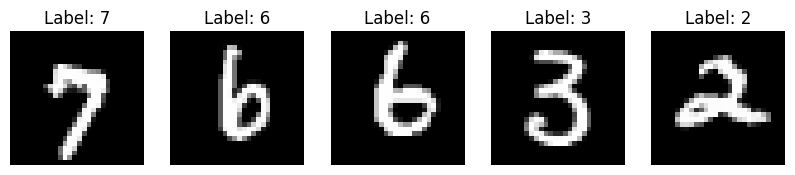

Batch Shape: torch.Size([64, 1, 28, 28])


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 1. Load and Normalize MNIST (Grayscale)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normalize to [-1, 1]
])

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Split trainset into train and validation (50k train, 10k val)
train_subset, val_subset = torch.utils.data.random_split(trainset, [50000, 10000])

trainloader = torch.utils.data.DataLoader(train_subset, batch_size=64, shuffle=True)
valloader = torch.utils.data.DataLoader(val_subset, batch_size=64, shuffle=False)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

# 2. Display 5 random images
dataiter = iter(trainloader)
images, labels = next(dataiter)

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    img = images[i].numpy().squeeze()
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis('off')
plt.show()

# 3. Print shapes
print(f"Batch Shape: {images.shape}")

Task 2: Architecture Design Experiment

Using device: cpu
Model A -> Params: 25450 | Time: 108.27s | Val Acc: 94.61%
Model B -> Params: 109386 | Time: 115.90s | Val Acc: 95.74%
Model C -> Params: 242762 | Time: 129.67s | Val Acc: 97.70%


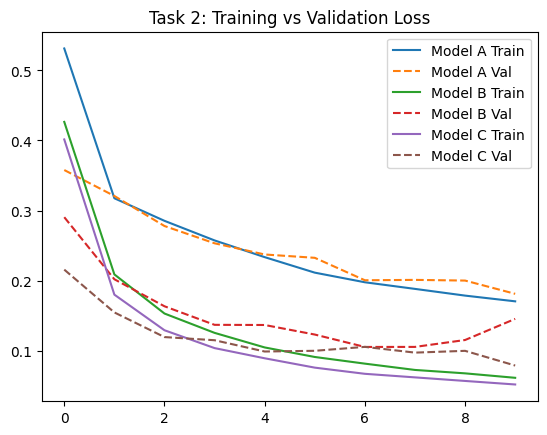

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Reusable training function
def train_and_evaluate(model, name, epochs=10):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses = [], []
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.view(inputs.shape[0], -1).to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_losses.append(running_loss / len(trainloader))

        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in valloader:
                inputs, labels = inputs.view(inputs.shape[0], -1).to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_losses.append(val_loss / len(valloader))

    end_time = time.time()
    val_acc = 100 * correct / total
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{name} -> Params: {params} | Time: {end_time-start_time:.2f}s | Val Acc: {val_acc:.2f}%")

    return train_losses, val_losses, val_acc, params, end_time-start_time

# Define Models
class ModelA(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(784, 32), nn.ReLU(), nn.Linear(32, 10))
    def forward(self, x): return self.net(x)

class ModelB(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 10))
    def forward(self, x): return self.net(x)

class ModelC(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 10))
    def forward(self, x): return self.net(x)

# Train and Plot
results = {}
for model, name in [(ModelA(), "Model A"), (ModelB(), "Model B"), (ModelC(), "Model C")]:
    t_loss, v_loss, acc, params, t_time = train_and_evaluate(model, name)
    results[name] = {'acc': acc, 'params': params, 'time': t_time}
    plt.plot(t_loss, label=f"{name} Train")
    plt.plot(v_loss, label=f"{name} Val", linestyle='--')

plt.title("Task 2: Training vs Validation Loss")
plt.legend()
plt.show()

Task 3: Underfitting vs Overfitting Analysis

Small Model -> Params: 3190 | Time: 162.25s | Val Acc: 11.65%
Large Model -> Params: 1764426 | Time: 398.54s | Val Acc: 97.68%


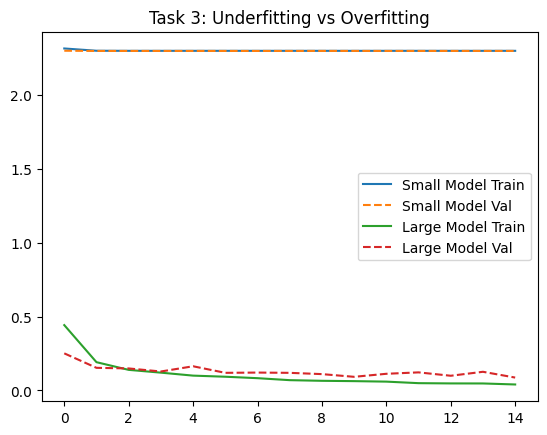

In [ ]:
class SmallModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(784, 4), nn.ReLU(), nn.Linear(4, 10))
    def forward(self, x): return self.net(x)

class LargeModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 1024), nn.ReLU(), nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, 512), nn.ReLU(), nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

for model, name in [(SmallModel(), "Small Model"), (LargeModel(), "Large Model")]:
    t_loss, v_loss, _, _, _ = train_and_evaluate(model, name, epochs=15) # 15 epochs to force overfitting
    plt.plot(t_loss, label=f"{name} Train")
    plt.plot(v_loss, label=f"{name} Val", linestyle='--')

plt.title("Task 3: Underfitting vs Overfitting")
plt.legend()
plt.show()

Task 4: Batch Normalization Study

In [14]:
class ModelB_BN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

# Check if 'results' dictionary is defined, and if not, initialize it.
# This assumes that if 'results' is not defined, the models from Task 2
# (Model A, B, C) have not been trained or their results are not in scope.
if 'results' not in locals() and 'results' not in globals():
    print("Warning: 'results' dictionary not found. Initializing it. ")
    print("Results for Model A, B, C will be missing if Task 2 was not executed.")
    results = {}

t_loss_bn, v_loss_bn, acc_bn, params_bn, time_bn = train_and_evaluate(ModelB_BN(), "Model B (BatchNorm)")
results["Model B (BatchNorm)"] = {'acc': acc_bn, 'params': params_bn, 'time': time_bn}

# Note: Compare these curves to Model B from Task 2 in your report.

Model B (BatchNorm) -> Params: 109770 | Time: 157.50s | Val Acc: 97.91%


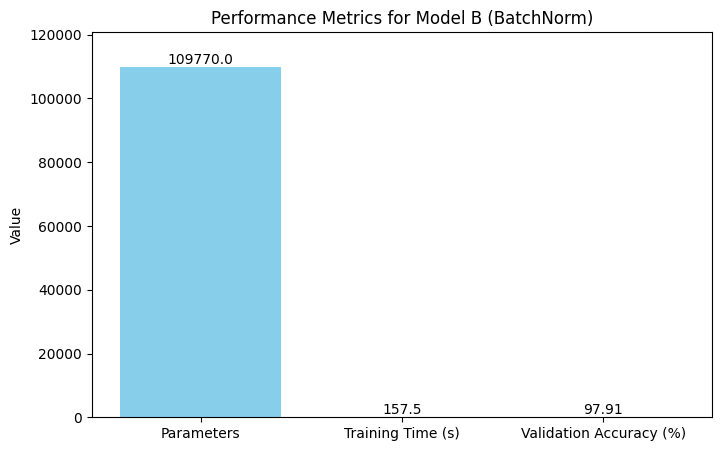

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure results dictionary is available
if 'results' not in locals() and 'results' not in globals():
    print("Error: 'results' dictionary not found. Please run previous relevant cells.")
else:
    model_name = "Model B (BatchNorm)"
    if model_name in results:
        data = results[model_name]
        metrics = ['Parameters', 'Training Time (s)', 'Validation Accuracy (%)']
        values = [data['params'], data['time'], data['acc']]

        fig, ax = plt.subplots(figsize=(8, 5))
        bars = ax.bar(metrics, values, color=['skyblue', 'lightcoral', 'lightgreen'])

        ax.set_ylabel('Value')
        ax.set_title(f'Performance Metrics for {model_name}')
        ax.ticklabel_format(style='plain', axis='y') # Prevent scientific notation for parameters

        # Add value labels on top of the bars
        for bar in bars:
            yval = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, yval + 0.05, round(yval, 2), ha='center', va='bottom')

        plt.ylim(0, max(values) * 1.1) # Adjust y-axis limit for better visualization
        plt.show()
    else:
        print(f"Error: '{model_name}' not found in the 'results' dictionary. Please check model name or ensure it was trained.")

Task 5: Error Analysis

100%|██████████| 9.91M/9.91M [00:00<00:00, 64.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.30MB/s]


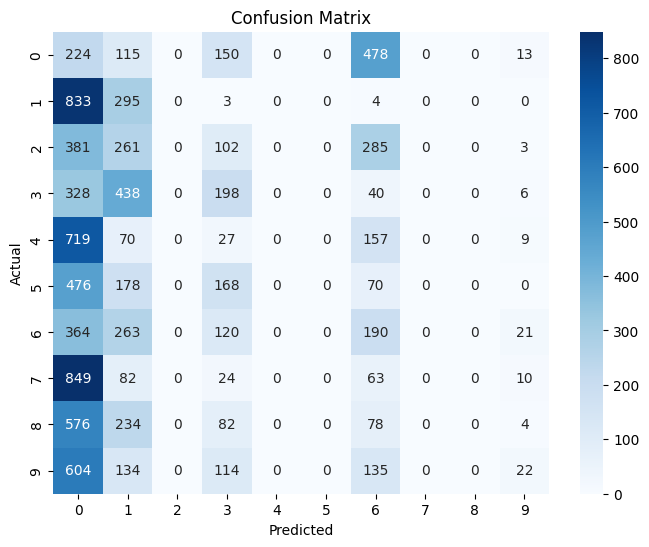

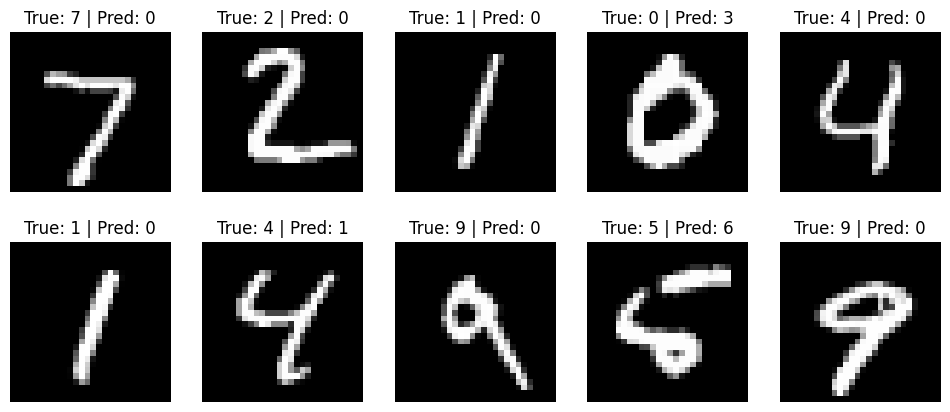

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn as nn # Added import for nn module
import torch # Added import for torch
import torchvision # Added import for torchvision
import torchvision.transforms as transforms # Added import for transforms

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data Loading for testset (to define testloader)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normalize to [-1, 1]
])
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

# Redefine ModelB_BN here to ensure it's in scope for error analysis
class ModelB_BN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

# Assuming ModelB_BN or Model C was your best. Let's use a trained ModelB_BN.
best_model = ModelB_BN().to(device)
# (In your notebook, just use the instance of the model you already trained)

best_model.eval()
all_preds, all_labels, misclassified_imgs, misclassified_preds, misclassified_true = [], [], [], [], []

with torch.no_grad():
    for inputs, labels in testloader:
        inputs_flat = inputs.view(inputs.shape[0], -1).to(device);
        outputs = best_model(inputs_flat)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

        # Find misclassifications
        for i in range(len(preds)):
            if preds[i] != labels[i].to(device):
                if len(misclassified_imgs) < 10:
                    misclassified_imgs.append(inputs[i].numpy().squeeze())
                    misclassified_preds.append(preds[i].item())
                    misclassified_true.append(labels[i].item())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Display 10 misclassified images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    if i < len(misclassified_imgs):
        ax.imshow(misclassified_imgs[i], cmap='gray')
        ax.set_title(f"True: {misclassified_true[i]} | Pred: {misclassified_preds[i]}")
        ax.axis('off')
plt.show()

Task 6: Model Efficiency Comparison
Compare all models in terms of:
Number of parameters
Training time
Accuracy
Present results in a table format.


https://docs.google.com/spreadsheets/d/1PXTEtZdgywvezK0v-f9rZJi4CshR2yVyuGlvUiUbGMU/edit?gid=785020442#gid=785020442

Bonus: Gradient Stability

Training Deep MLP without BN...
Deep w/o BN -> Params: 217354 | Time: 194.81s | Val Acc: 95.74%
Training Deep MLP with BN...
Deep w/ BN -> Params: 219402 | Time: 196.81s | Val Acc: 97.86%


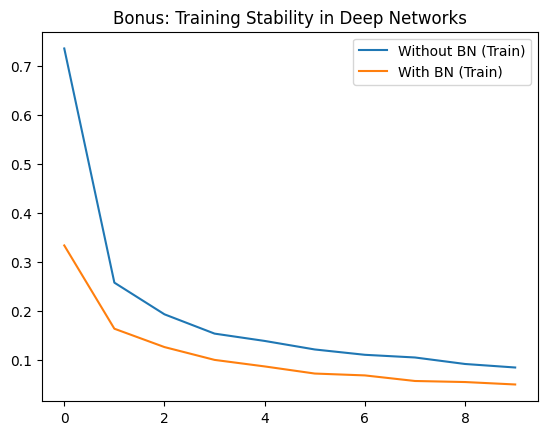

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time
import torchvision
import torchvision.transforms as transforms

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load and Normalize MNIST (Grayscale) - Copied from Task 1
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normalize to [-1, 1]
])

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Split trainset into train and validation (50k train, 10k val)
train_subset, val_subset = torch.utils.data.random_split(trainset, [50000, 10000])

trainloader = torch.utils.data.DataLoader(train_subset, batch_size=64, shuffle=True)
valloader = torch.utils.data.DataLoader(val_subset, batch_size=64, shuffle=False)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

# Reusable training function
def train_and_evaluate(model, name, epochs=10):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses = [], []
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.view(inputs.shape[0], -1).to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_losses.append(running_loss / len(trainloader))

        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in valloader:
                inputs, labels = inputs.view(inputs.shape[0], -1).to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_losses.append(val_loss / len(valloader))

    end_time = time.time()
    val_acc = 100 * correct / total
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{name} -> Params: {params} | Time: {end_time-start_time:.2f}s | Val Acc: {val_acc:.2f}%")

    return train_losses, val_losses, val_acc, params, end_time-start_time

class DeepMLP(nn.Module):
    def __init__(self, use_bn=False):
        super().__init__()
        layers = [nn.Linear(784, 128)]
        if use_bn: layers.append(nn.BatchNorm1d(128))
        layers.append(nn.ReLU())

        for _ in range(7): # 8 hidden layers total
            layers.append(nn.Linear(128, 128))
            if use_bn: layers.append(nn.BatchNorm1d(128))
            layers.append(nn.ReLU())

        layers.append(nn.Linear(128, 10))
        self.net = nn.Sequential(*layers)

    def forward(self, x): return self.net(x)

print("Training Deep MLP without BN...")
t_loss_deep, v_loss_deep, _, _, _ = train_and_evaluate(DeepMLP(use_bn=False), "Deep w/o BN", epochs=10)

print("Training Deep MLP with BN...")
t_loss_deep_bn, v_loss_deep_bn, _, _, _ = train_and_evaluate(DeepMLP(use_bn=True), "Deep w/ BN", epochs=10)

plt.plot(t_loss_deep, label="Without BN (Train)")
plt.plot(t_loss_deep_bn, label="With BN (Train)")
plt.title("Bonus: Training Stability in Deep Networks")
plt.legend()
plt.show()